In [6]:
import pickle
import pandas as pd
import numpy as np
from pypcd4 import PointCloud
import cv2
from PIL import Image

In [7]:
# Необходимые столбцы
CUBOIDS_COLUMNS = ['label', 'yaw', 'position.x', 'position.y', 'dimensions.x', 'dimensions.y']
pcd_columns = ['x', 'y', 'z', 'i']
BEV_LABELS = ['Car', 'Bus', 'Pedestrian', 'Bus', 'Pickup Truck']

# Квадрат для препроцессинга
PCD_AREA_WIDTH = 50
PCD_AREA_HEIGHT = 50

# Размер изображения после препроцессинга
BEV_WIDTH = 640
BEV_HEIGHT = 640

# Ограничения по дальности лидара
WIDTH_MAGIC = 50
HEIGHT_MAGIC = 50

In [8]:
with open('./tests/annotations/cuboids/00.pkl', 'rb') as f:
    cuboids_data = pickle.load(f)
    cuboids_data = cuboids_data[CUBOIDS_COLUMNS]
    cuboids_data = cuboids_data[cuboids_data['label'].isin(['Car', 'Bus', 'Pedestrian', 'Bus', 'Pickup Truck'])]
    cuboids_array = cuboids_data.to_numpy()

with open('./tests/lidar/00.pkl', 'rb') as f:
    lidar_data = pickle.load(f)

/tmp/ipykernel_57508/1917713777.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  cuboids_data = pickle.load(f)
/tmp/ipykernel_57508/1917713777.py:8: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  lidar_data = pickle.load(f)


In [13]:
# Из чего состоят
print(cuboids_data[cuboids_columns].iloc[0])
# print(lidar_data.iloc[0])

NameError: name 'cuboids_columns' is not defined

In [9]:
points_array = lidar_data[pcd_columns].to_numpy()
# cuboids_array = cuboids_data[cuboids_columns].to_numpy()
# pcd = PointCloud.from_xyzi_points(points_array)

In [18]:
def xywhr_to_4xy(xywhr):
    def rotate_x(a):
        cos_a = np.cos(a)
        sin_a = np.sin(a)
        return lambda x, y: x * cos_a + y * sin_a

    def rotate_y(a):
        cos_a = np.cos(a)
        sin_a = np.sin(a)
        return lambda x, y: -x * sin_a + y * cos_a

    start_x1 = - xywhr[:, 2] / 2
    start_x2 = xywhr[:, 2] / 2
    start_y1 = xywhr[:, 3] / 2
    start_y2 = -xywhr[:, 3] / 2
    
    # print(start_x1)
    rotate_x_func = rotate_x(xywhr[:, 4] - (3.14 / 2))
    rotate_y_func = rotate_y(xywhr[:, 4] - (3.14 / 2))
    
    # rotate_x_func = rotate_x(xywhr[:, 4] * 0)
    # rotate_y_func = rotate_y(xywhr[:, 4] * 0)
    
    points_4xy = np.zeros((xywhr.shape[0], 8))
    
    points_4xy[:, 0] = np.round(rotate_x_func(start_x1, start_y1), 4) + xywhr[:, 1]
    points_4xy[:, 2] = np.round(rotate_x_func(start_x2, start_y1), 4) + xywhr[:, 1]
    points_4xy[:, 4] = np.round(rotate_x_func(start_x1, start_y2), 4) + xywhr[:, 1]
    points_4xy[:, 6] = np.round(rotate_x_func(start_x2, start_y2), 4) + xywhr[:, 1]
    
    points_4xy[:, 1] = np.round(rotate_y_func(start_x1, start_y1), 4) + xywhr[:, 0]
    points_4xy[:, 3] = np.round(rotate_y_func(start_x2, start_y1), 4) + xywhr[:, 0]
    points_4xy[:, 5] = np.round(rotate_y_func(start_x1, start_y2), 4) + xywhr[:, 0]
    points_4xy[:, 7] = np.round(rotate_y_func(start_x2, start_y2), 4) + xywhr[:, 0]

    return points_4xy


def get_label_indexes(label_col):
    label_indexes = np.asarray([BEV_LABELS.index(x) for x in label_col])
    return label_indexes

def get_normalized_cuboid(cuboid_data, row, col, x_min_border, y_min_border):
    x_min_area_border = x_min_border + row * PCD_AREA_WIDTH
    y_min_area_border = y_min_border + col * PCD_AREA_HEIGHT
    
    normalized_cuboid = cuboid_data.copy()
    
    print(normalized_cuboid[2])
    normalized_cuboid[2] = (np.float32(normalized_cuboid[2]) - x_min_area_border) / PCD_AREA_WIDTH
    print(f"norm: {normalized_cuboid[2]}")
    normalized_cuboid[3] = (np.float32(normalized_cuboid[3]) - y_min_area_border) / PCD_AREA_HEIGHT
    
    normalized_cuboid[4] = np.float32(normalized_cuboid[4]) / PCD_AREA_WIDTH
    normalized_cuboid[5] = np.float32(normalized_cuboid[5]) / PCD_AREA_HEIGHT
    
    return normalized_cuboid


def get_labels(cuboid_data):
    label_data = np.zeros((cuboid_data.shape[0], 9))

    label_data[:, 0] = get_label_indexes(cuboid_data[:, 0])

    xywhr = np.zeros((cuboid_data.shape[0], 5))
    xywhr[:, :4] = cuboid_data[:, 2:6]
    xywhr[:, 4] = cuboid_data[:, 2]

    cuboid_points = xywhr_to_4xy(xywhr)
    label_data[:, 1:] = cuboid_points

    return label_data

In [14]:
# Определяем края для обучения
x_min = np.min(cuboids_array[:, 2])
x_max = np.max(cuboids_array[:, 2])
x_max_dim = np.max(cuboids_array[:, 4])

y_min = np.min(cuboids_array[:, 3])
y_max = np.max(cuboids_array[:, 3])
y_max_dim = np.max(cuboids_array[:, 5])

x_min_border = max(x_min - x_max_dim, -WIDTH_MAGIC)
x_max_border = min(x_max + x_max_dim, WIDTH_MAGIC)

y_min_border = max(y_min - y_max_dim, -HEIGHT_MAGIC)
y_max_border = min(y_max + y_max_dim, HEIGHT_MAGIC)

print(f"Зона для обучения: [({x_min_border}, {y_min_border}) : ({x_max_border}, {y_max_border})]")

# y (cols)
# |
# |
# 0 --- x  (rows)

row_num = int((x_max_border - x_min_border - 1) // PCD_AREA_WIDTH + 1)
col_num = int((y_max_border - y_min_border - 1) // PCD_AREA_HEIGHT + 1)
print(f"{row_num}x{col_num} зон для обучения")

# Для нормализации z
z_min = np.min(points_array[:, 2])
z_max = np.max(points_array[:, 2])

Зона для обучения: [(-50, -50) : (50, 50)]
2x2 зон для обучения


In [20]:
# Распределение всех точек по необходимым зонам (row_num x col_num)
def get_point_areas(points_array, row_num, col_num, x_min_border, y_min_border):
    point_areas = [[[] for _ in range((col_num))] for _ in range(row_num)]

    for point in points_array:
        
        x_idx = int((point[0] - x_min_border) // PCD_AREA_WIDTH)
        y_idx = int((point[1] - y_min_border) // PCD_AREA_HEIGHT)
        if x_idx >= 0 and y_idx >= 0 and x_idx < row_num and y_idx < col_num:
            point_areas[x_idx][y_idx].append(point)
    
    return point_areas

def get_cuboid_areas(cuboids_array, row_num, col_num, x_min_border, y_min_border):
    cuboid_areas = [[[] for _ in range((col_num))] for _ in range(row_num)]

    for cuboid in cuboids_array:
        x_idx = int((cuboid[2] - x_min_border) // PCD_AREA_WIDTH)
        y_idx = int((cuboid[3] - y_min_border) // PCD_AREA_HEIGHT)
        if x_idx >= 0 and y_idx >= 0 and x_idx < row_num and y_idx < col_num:
            normalize_cuboid = get_normalized_cuboid(cuboid, x_idx, y_idx, x_min_border, y_min_border)
            cuboid_areas[x_idx][y_idx].append(normalize_cuboid)
    
    return cuboid_areas

point_areas = get_point_areas(points_array, row_num, col_num, x_min_border, y_min_border)
# print(cuboids_array)
cuboid_areas = get_cuboid_areas(cuboids_array, row_num, col_num, x_min_border, y_min_border)
# print(cuboid_areas)
# print(len(point_areas))
# print(np.max(np.asarray(point_areas[0][0])[:, 0]))


20.759
norm: 0.4151800274848938
26.281
norm: 0.5256199836730957
-44.205
norm: 0.1158999651670456
-30.673
norm: 0.3865399956703186
-10.899
norm: 0.7820199728012085
-4.207
norm: 0.9158599972724915
8.725
norm: 0.1745000034570694
-6.854
norm: 0.8629199862480164
34.919
norm: 0.6983799934387207
40.027
norm: 0.800540030002594
25.906
norm: 0.5181199908256531
-8.704
norm: 0.8259199261665344
-19.084
norm: 0.6183199882507324
-13.885
norm: 0.7222999334335327
33.87
norm: 0.6773999929428101
-13.929
norm: 0.7214199900627136
-32.871
norm: 0.34258002042770386
-40.235
norm: 0.19529998302459717
-24.022
norm: 0.5195600390434265
20.917
norm: 0.4183399975299835
-20.031
norm: 0.5993800163269043
-5.044
norm: 0.899120032787323
-22.066
norm: 0.55867999792099
-6.462
norm: 0.8707600235939026
-5.559
norm: 0.8888200521469116
30.894
norm: 0.6178799867630005
-16.115
norm: 0.6777000427246094
-18.269
norm: 0.6346200108528137
3.947
norm: 0.0789400041103363
-39.265
norm: 0.21470001339912415
-23.454
norm: 0.53091996908187

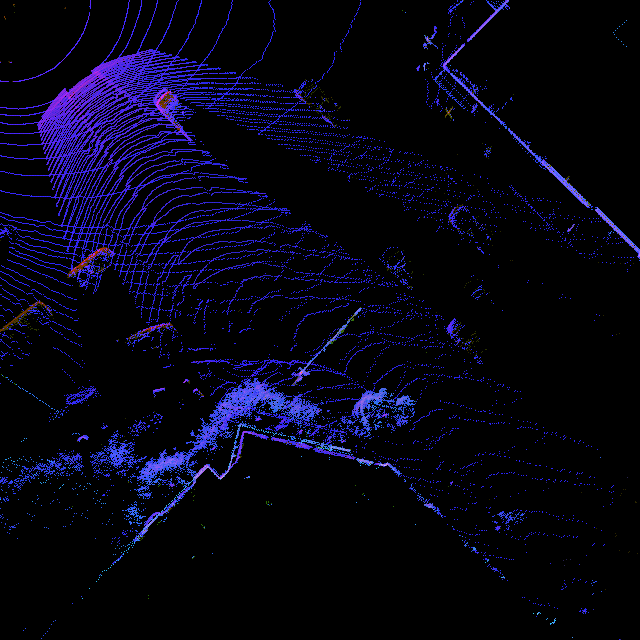

In [21]:
# Create (x, y): (counts, maxZ) dict
def get_CoordToCountValInt_dict(points):
    coord_to_countval = dict()
    for point in points:
        if coord_to_countval.get((point[0], point[1])) == None:
            coord_to_countval[((point[0], point[1]))] = [1, point[2], point[3]]
        else:
            coord_to_countval[((point[0], point[1]))][0] += 1
    return coord_to_countval


def pcd_to_img_map(points_array, x_idx, y_idx, x_min_border, y_min_border, z_min, z_max):
    x_min_area_border = x_min_border + x_idx * PCD_AREA_WIDTH
    y_min_area_border = y_min_border + y_idx * PCD_AREA_HEIGHT

    # Нормализуем x,y [0: 1]
    points_array[:, 0] = (points_array[:, 0] - x_min_area_border) / PCD_AREA_WIDTH
    points_array[:, 1] = (points_array[:, 1] - y_min_area_border) / PCD_AREA_HEIGHT

    # Приводим x,y к [0: BEV_H/BEV_W]
    points_array[:, 0] = np.int32(points_array[:, 0] * BEV_WIDTH)
    points_array[:, 1] = np.int32(points_array[:, 1] * BEV_HEIGHT)

    # Приводим z к [0, 1]
    points_array[:, 2] = (points_array[:, 2] - z_min) / (z_max - z_min)

    # Сортируем (увел х, увел y, умен z)
    ix = np.lexsort((-points_array[:, 2], points_array[:, 1], points_array[:, 0]))
    points_array = points_array[ix]

    height_map = np.zeros((BEV_HEIGHT, BEV_WIDTH))
    density_map = np.zeros((BEV_HEIGHT, BEV_WIDTH))
    intensity_map = np.zeros((BEV_HEIGHT, BEV_WIDTH))

    points_array[:, 0] = np.minimum(np.maximum(points_array[:, 0], 0), BEV_HEIGHT - 1)
    points_array[:, 1] = np.minimum(np.maximum(points_array[:, 1], 0), BEV_WIDTH - 1)

    coord_to_countval = get_CoordToCountValInt_dict(points_array)
    # points_array = points_array[ix]

    for ((x, y), (c, z, i)) in coord_to_countval.items():
        density_map[int(x)][int(y)] = min(1.0, np.log(c + 1) / np.log(64))
        height_map[int(x)][int(y)] = z
        intensity_map[int(x)][int(y)] = i

    img_map = np.zeros([BEV_HEIGHT, BEV_WIDTH, 3])
    img_map[:,:,0] = density_map
    img_map[:,:,1] = height_map
    # img_map[:,:,2] = height_map
    # img_map[:,:,2] = np.full([BEV_HEIGHT, BEV_WIDTH ], 1)
    img_map[:,:,2] = intensity_map
    
    return img_map

temp = np.asarray(point_areas[1][1])
img = pcd_to_img_map(temp, 1, 1, x_min_border, y_min_border, z_min, z_max)

bevImage = img * 255

# cv2.imshow("BEV", img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
cv2.imwrite("test.png", bevImage.astype(np.uint8))
img = Image.fromarray(bevImage.astype(np.uint8))
img

In [29]:
for x in range(1, row_num):
    for y in range(1, col_num):
        cur_area_point_arr = np.asarray(point_areas[x][y])
        cur_area_cuboid_arr = np.asarray(cuboid_areas[x][y])

        if len(cur_area_cuboid_arr) * len(cur_area_point_arr) == 0:
            continue
        
        img = pcd_to_img_map(cur_area_point_arr, x, y, x_min_border, y_min_border, z_min, z_max)
        bevImage = img * 255
        
        # print(cur_area_cuboid_arr[:, 2:] * 640)
        
        print(cur_area_cuboid_arr[:, 1])
        area_labels = get_labels(cur_area_cuboid_arr)
        area_labels = area_labels[:, 1:] * 640
        # print(area_labels)
        
        for cuboid in area_labels:
            # cnt = np.array([cuboid[0:2][::-1], cuboid[2:4][::-1], cuboid[4:6][::-1], cuboid[6:8][::-1]], dtype=np.int32)
            cnt = np.array([cuboid[0:2], cuboid[4:6], cuboid[6:8], cuboid[2:4]], dtype=np.int32)
            # print(points)
            cv2.drawContours(img, [cnt], -1, (0, 255, 0), 3)
        cv2.imshow("Contour by 4 points", img)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
            
        cv2.imwrite(f"test{x}{y}.png", bevImage.astype(np.uint8))


[2.3803062137948943 2.3803062137948943 2.336156274423194
 0.6533613875004984 0.6708146800204418 0.30865973288720333
 2.3988389924569615 2.3674233637175126 2.3639324074170753
 -0.7813873611914692 2.3988389924569615 0.32854863237994314
 -0.7813873611914692 2.3639324074170753 2.3674233637175126]
